## Background :
- We have diner reviews from the Yelp website to determine which dishes people liked and disliked of restaurant 'Big bite'
- The restaurant owner also gave the list of menu items and their common alternate spellings.

## Objective :
- To identify whether there are any foods on restaurant menu that diners find disappointing.

## Solution :
- group reviews by restaurant's menu items
- calculate the average rating for reviews that mentioned each item.
- find foods items mentioned in reviews with low scores, so the restaurant can fix the recipe or remove those foods from the menu.


In [6]:
# import pandas library
import pandas as pd

In [4]:
# Load in the data from JSON file
data = pd.read_json('./resources/restaurant.json')
data.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
109,lDJIaF4eYRF4F7g6Zb9euw,lb0QUR5bc4O-Am4hNq9ZGg,r5PLDU-4mSbde5XekTXSCA,4,2,0,0,I used to work food service and my manager at ...,2013-01-27 17:54:54
1013,vvIzf3pr8lTqE_AOsxmgaA,MAmijW4ooUzujkufYYLMeQ,r5PLDU-4mSbde5XekTXSCA,4,0,0,0,We have been trying Eggplant sandwiches all ov...,2015-04-15 04:50:56
1204,UF-JqzMczZ8vvp_4tPK3bQ,slfi6gf_qEYTXy90Sw93sg,r5PLDU-4mSbde5XekTXSCA,5,1,0,0,Amazing Steak and Cheese... Better than any Ph...,2011-03-20 00:57:45
1251,geUJGrKhXynxDC2uvERsLw,N_-UepOzAsuDQwOUtfRFGw,r5PLDU-4mSbde5XekTXSCA,1,0,0,0,Although I have been going to DeFalco's for ye...,2018-07-17 01:48:23
1354,aPctXPeZW3kDq36TRm-CqA,139hD7gkZVzSvSzDPwhNNw,r5PLDU-4mSbde5XekTXSCA,2,0,0,0,"Highs: Ambience, value, pizza and deserts. Thi...",2018-01-21 10:52:58


In [5]:

menu = ["Cheese Steak", "Cheesesteak", "Steak and Cheese", "Italian Combo", "Tiramisu", "Cannoli",
        "Chicken Salad", "Chicken Spinach Salad", "Meatball", "Pizza", "Pizzas", "Spaghetti",
        "Bruchetta", "Eggplant", "Italian Beef", "Purista", "Pasta", "Calzones",  "Calzone",
        "Italian Sausage", "Chicken Cutlet", "Chicken Parm", "Chicken Parmesan", "Gnocchi",
        "Chicken Pesto", "Turkey Sandwich", "Turkey Breast", "Ziti", "Portobello", "Reuben",
        "Mozzarella Caprese",  "Corned Beef", "Garlic Bread", "Pastrami", "Roast Beef",
        "Tuna Salad", "Lasagna", "Artichoke Salad", "Fettuccini Alfredo", "Chicken Parmigiana",
        "Grilled Veggie", "Grilled Veggies", "Grilled Vegetable", "Mac and Cheese", "Macaroni",  
         "Prosciutto", "Salami"]

### Step 1: Find items in one review
As a first step, extract the foods mentioned in a single review.
Since menu items are multiple tokens long, we'll use PhraseMatcher which can match series of tokens.

In [21]:
import spacy
from spacy.matcher import PhraseMatcher

index_of_review_to_test_on = 20
text_to_test_on = data.text.iloc[index_of_review_to_test_on]

print("REVIEW SAMPLE",text_to_test_on)

nlp = spacy.blank('en')
review_doc = nlp(text_to_test_on)

matcher = PhraseMatcher(nlp.vocab, attr='LOWER')
menu_tokens_list = [nlp(item) for item in menu]
matcher.add("MENU", menu_tokens_list)
matches = matcher(review_doc)

print("MATCHES", matches)

REVIEW SAMPLE This place is my new favorite. We went there for the first time tonight and was blown away. The cheesesteak was by far the best I've ever had. We ordered the fettuccini Alfredo with chicken as well. It was also really good but I couldn't get past how amazing the cheesesteak was. Best Italian restaurant I've ever eaten at. Highly suggest!
MATCHES [(8291075388056826051, 21, 22), (8291075388056826051, 35, 37), (8291075388056826051, 56, 57)]


In [23]:
# Print the tokens of menu itmes found in review example taken
# way 1 of printing token
# for (match_id,start,end) in matches:
#     print(review_doc[start:end])
    
for match in matches:    
    print(f"Token number {match[1]}: {review_doc[match[1]:match[2]]}")

Token number 21: cheesesteak
Token number 35: fettuccini Alfredo
Token number 56: cheesesteak


# Step 2 :  Matching on the whole dataset
run this matcher over the whole dataset and collect ratings for each menu item. Each review has a rating, review.stars. For each item that appears in the review text (review.text), append the review's rating to a list of ratings for that item. The lists are kept in a dictionary item_ratings.

To get the matched phrases, you can reference the PhraseMatcher documentation for the structure of each match object:

A list of (match_id, start, end) tuples, describing the matches. A match tuple describes a span doc[start:end]. The match_id is the ID of the added match pattern.

In [24]:
from collections import defaultdict

# item_ratings is a dictionary of lists. If a key doesn't exist in item_ratings,
# the key is added with an empty list as the value.
item_ratings = defaultdict(list)

for idx, review in data.iterrows():
    doc = nlp(review.text)
    # Using the matcher from the previous exercise
    matches = matcher(doc)
    
    # Create a set of the items found in the review text
    found_items = set([doc[match[1]:match[2]].lower_ for match in matches])
    
    # Update item_ratings with rating for each item in found_items
    # Transform the item strings to lowercase to make it case insensitive
    for item in found_items:
        item_ratings[item].append(review.stars)


In [28]:
print(item_ratings)

defaultdict(<class 'list'>, {'chicken parmigiana': [4, 5, 4, 5, 5, 5, 5, 5, 4, 4, 4, 3, 4, 5, 5, 4, 5], 'eggplant': [4, 3, 1, 5, 4, 3, 4, 3, 4, 5, 4, 5, 5, 5, 3, 5, 5, 5, 4, 5, 4, 5, 4, 4, 4, 5, 5, 5, 2, 5, 5, 5, 5, 4, 3, 5, 5, 5, 5, 5, 5, 4, 2, 4, 3, 5, 5, 5, 3, 4, 4, 5, 5, 2, 4, 4, 5, 5, 2, 5, 2, 5, 4, 4, 3, 5, 1, 5, 5], 'steak and cheese': [5, 5, 5, 5, 4, 5, 5, 5, 5], 'pizza': [5, 2, 3, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 2, 5, 1, 4, 3, 5, 5, 5, 4, 5, 5, 5, 5, 3, 3, 4, 4, 5, 5, 5, 5, 2, 3, 5, 5, 5, 5, 5, 4, 5, 4, 4, 4, 5, 4, 4, 3, 5, 5, 5, 4, 5, 5, 5, 4, 5, 3, 3, 5, 4, 4, 5, 5, 5, 4, 5, 4, 5, 1, 4, 5, 3, 5, 5, 4, 5, 5, 5, 5, 5, 5, 4, 2, 5, 4, 5, 3, 5, 5, 5, 5, 5, 1, 4, 4, 5, 3, 4, 5, 5, 5, 5, 4, 2, 5, 5, 2, 5, 5, 2, 5, 5, 5, 4, 5, 5, 5, 1, 5, 5, 5, 5, 5, 4, 5, 5, 4, 4, 5, 5, 5, 5, 5, 4, 5, 5, 4, 5, 1, 5, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 3, 4, 5, 5, 5, 2, 3, 5, 5, 5, 5, 4, 4, 4, 3, 5, 5, 5, 3, 2, 5, 1, 5, 5, 3, 5, 5, 4, 4, 5, 5, 4, 3, 4, 4, 4, 4, 2, 5, 3, 5, 4, 4

In [29]:
# Calculate the mean ratings for each menu item as a dictionary
mean_ratings = {item: sum(ratings)/len(ratings) for item, ratings in item_ratings.items()}
# Find the worst, and write it as a string in worst_item. This can be multiple lines of code if you want.
worst_item = sorted(mean_ratings, key=mean_ratings.get)[0]


In [ ]:
## Step 3 : Inferences
- Similar to the mean ratings, we can calculate the number of reviews for each item.
- 

In [32]:
# print worst item as per review
print(worst_item)

chicken cutlet


In [33]:
# rating of worst item as per review
print(mean_ratings[worst_item])

3.4


In [34]:
counts = {item: len(ratings) for item, ratings in item_ratings.items()}

item_counts = sorted(counts, key=counts.get, reverse=True)
for item in item_counts:
    print(f"{item:>25}{counts[item]:>5}")

                    pizza  265
                    pasta  206
                 meatball  128
              cheesesteak   97
             cheese steak   76
                  cannoli   72
                  calzone   72
                 eggplant   69
                  purista   63
                  lasagna   59
          italian sausage   53
               prosciutto   50
             chicken parm   50
             garlic bread   39
                  gnocchi   37
                spaghetti   36
                 calzones   35
                   pizzas   32
                   salami   28
            chicken pesto   27
             italian beef   25
                 tiramisu   21
            italian combo   21
                     ziti   21
         chicken parmesan   19
       chicken parmigiana   17
               portobello   14
           mac and cheese   11
           chicken cutlet   10
         steak and cheese    9
                 pastrami    9
               roast beef    7
       f

In [54]:
sorted_ratings = sorted(mean_ratings, key=mean_ratings.get)

worst_menu_items =[]
worst_menu_ratings =[]
worst_menu_counts=[]
print("Worst rated menu items:")
for item in sorted_ratings[:10]:
    print(f"{item:20} Ave rating: {mean_ratings[item]:.2f} \tcount: {counts[item]}")
    worst_menu_items.append(item)
    worst_menu_ratings.append(round(mean_ratings[item],2))
    worst_menu_counts.append(counts[item])
print("\n\nBest rated menu items:")
for item in sorted_ratings[-10:]:
    print(f"{item:20} Ave rating: {mean_ratings[item]:.2f} \tcount: {counts[item]}")
    
print(worst_menu_items)       
print(worst_menu_ratings)    
print(worst_menu_counts) 

Worst rated menu items:
chicken cutlet       Ave rating: 3.40 	count: 10
turkey sandwich      Ave rating: 3.80 	count: 5
spaghetti            Ave rating: 3.89 	count: 36
italian beef         Ave rating: 3.92 	count: 25
tuna salad           Ave rating: 4.00 	count: 5
macaroni             Ave rating: 4.00 	count: 5
italian combo        Ave rating: 4.05 	count: 21
garlic bread         Ave rating: 4.13 	count: 39
roast beef           Ave rating: 4.14 	count: 7
eggplant             Ave rating: 4.16 	count: 69


Best rated menu items:
chicken pesto        Ave rating: 4.56 	count: 27
chicken salad        Ave rating: 4.60 	count: 5
purista              Ave rating: 4.67 	count: 63
prosciutto           Ave rating: 4.68 	count: 50
reuben               Ave rating: 4.75 	count: 4
steak and cheese     Ave rating: 4.89 	count: 9
artichoke salad      Ave rating: 5.00 	count: 5
fettuccini alfredo   Ave rating: 5.00 	count: 6
turkey breast        Ave rating: 5.00 	count: 1
corned beef          Ave ratin

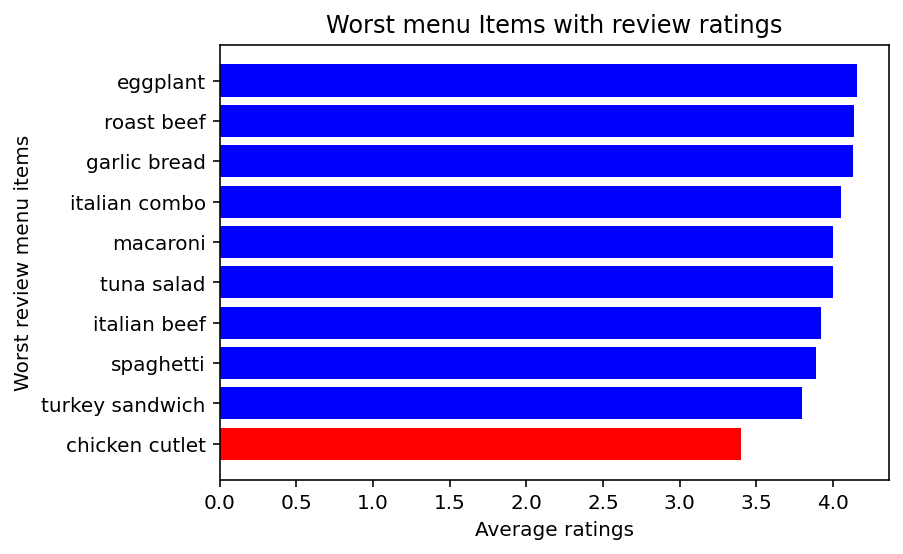

In [68]:
import matplotlib.pyplot as plt

col = []
for val in worst_menu_ratings:
    if val < 3.5:
        col.append('red')
    else:
        col.append('blue')

plt.barh(worst_menu_items, worst_menu_ratings,color=col)

# setting label of y-axis
plt.ylabel("Worst review menu items")  
# setting label of x-axis
plt.xlabel("Average ratings") 
plt.title("Worst menu Items with review ratings")
plt.show()